In [1]:
!pip install pandas numpy scikit-learn nltk matplotlib seaborn wordcloud

In [2]:
import pandas as pd
import numpy as np
import re
import string
import nltk

import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vasav\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\vasav\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\vasav\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Task 4 – Sentiment Analysis

## Objective

The objective of this project is to build a machine learning model
that classifies product reviews into three sentiment categories:

- Positive
- Negative
- Neutral

Natural Language Processing (NLP) techniques are used to preprocess
the text and convert it into numerical features using TF-IDF.

Two machine learning classification algorithms are trained and
compared:

1. Multinomial Naive Bayes
2. Logistic Regression

The models are evaluated using accuracy, precision, recall, F1-score,
and confusion matrices.

In [4]:
df = pd.read_csv("product_reviews.csv")

df.head()

,Window Name,Username,User ID,Review,Sentiment
0,Amazon,PriyaS_93,U1001,The product stopped working after a week.,Negative
1,Flipkart,Vinay_47,U1002,"The delivery was late, and the product packagi...",Negative
2,Amazon,AmitB_87,U1003,"This smartwatch is stylish, lightweight, and t...",Positive
3,Amazon,RohitP_86,U1004,"It's fine for casual use, but not professional...",Neutral
4,Flipkart,MeeraJain_85,U1005,Very bad customer service experience.,Negative


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1000
Number of columns: 5


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Window Name  1000 non-null   str  
 1   Username     1000 non-null   str  
 2   User ID      1000 non-null   str  
 3   Review       1000 non-null   str  
 4   Sentiment    1000 non-null   str  
dtypes: str(5)
memory usage: 121.0 KB


In [7]:
df.isnull().sum()

Window Name    0
Username       0
User ID        0
Review         0
Sentiment      0
dtype: int64

In [8]:
df['Sentiment'].value_counts()

Sentiment
Neutral     355
Positive    331
Negative    314
Name: count, dtype: int64

In [9]:
df['Sentiment'].value_counts()

Sentiment
Neutral     355
Positive    331
Negative    314
Name: count, dtype: int64

## Dataset Description

The dataset contains 1,000 product reviews from platforms such as
Amazon and Flipkart.

The important columns for sentiment analysis are:

- `Review` – contains the customer review text.
- `Sentiment` – contains the sentiment label.

The sentiment classes are Positive, Negative, and Neutral.

The classes are relatively balanced, which is useful for training
and evaluating a multi-class classification model.

In [10]:
print("Total reviews:", len(df))
print("Unique reviews:", df['Review'].nunique())
print("Duplicate reviews:", df['Review'].duplicated().sum())

Total reviews: 1000
Unique reviews: 15
Duplicate reviews: 985


## Dataset Quality Observation

The dataset contains repeated review texts. Although there are 1,000
records, many reviews use the same text repeatedly.

This may cause machine learning models to achieve unusually high
performance because the same or very similar texts can occur in both
the training and testing sets.

Therefore, the evaluation results should be interpreted carefully.
A larger dataset with more diverse and naturally written reviews would
provide a more realistic estimate of model performance.

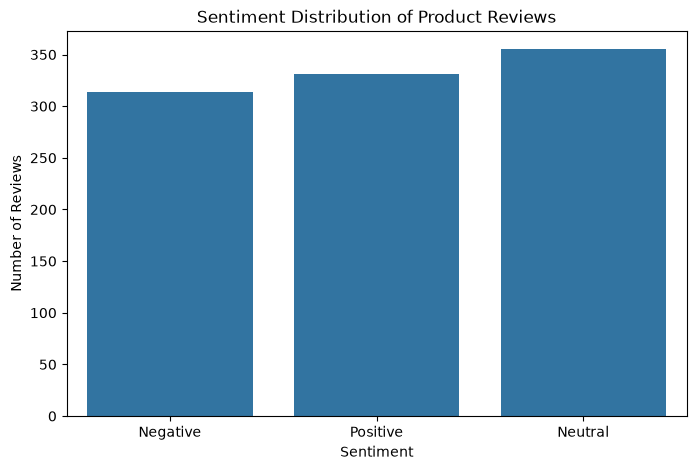

In [11]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Sentiment'
)

plt.title('Sentiment Distribution of Product Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

## Sentiment Distribution

The bar chart shows the distribution of the three sentiment classes
in the dataset.

The dataset contains a reasonably balanced number of Positive,
Negative, and Neutral reviews, which is beneficial for multi-class
classification.

In [12]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

In [13]:
def preprocess_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Tokenization
    tokens = text.split()

    # Stopword removal
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    # Join tokens back into text
    return ' '.join(tokens)

In [14]:
df['Clean_Review'] = df['Review'].apply(preprocess_text)

df[['Review', 'Clean_Review']].head()

,Review,Clean_Review
0,The product stopped working after a week.,product stopped working week
1,"The delivery was late, and the product packagi...",delivery late product packaging slightly damaged
2,"This smartwatch is stylish, lightweight, and t...",smartwatch stylish lightweight track fitness p...
3,"It's fine for casual use, but not professional...",fine casual use professional work
4,Very bad customer service experience.,bad customer service experience


## Text Preprocessing

Text preprocessing is necessary because machine learning algorithms
cannot directly understand raw text.

The following preprocessing operations were performed:

1. Lowercase conversion – converts all text to a consistent case.
2. Punctuation removal – removes unnecessary punctuation marks.
3. Number removal – removes numerical characters.
4. Tokenization – splits text into individual words.
5. Stopword removal – removes common words such as "the", "is", and
   "and".
6. Lemmatization – converts words into their base form where possible.

These steps reduce noise and create cleaner input for feature
extraction.

## TF-IDF Feature Extraction

TF-IDF stands for Term Frequency-Inverse Document Frequency.

Machine learning algorithms require numerical input, but reviews are
textual data. TF-IDF converts the text into numerical feature vectors.

TF-IDF gives importance to words based on how frequently they occur
in a particular document and how common they are across all
documents.

Words that are common across many documents receive lower importance,
while words that help distinguish documents receive higher importance.

TF-IDF is therefore used to represent the cleaned reviews as
numerical features for the machine learning models.

In [15]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['Clean_Review'])

y = df['Sentiment']

In [16]:
print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (1000, 64)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [18]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 800
Testing samples: 200


## Train-Test Split

The dataset was divided into training and testing sets using an
80/20 split.

- 80% of the data is used for training.
- 20% of the data is used for testing.

The `stratify` parameter is used to maintain a similar proportion of
Positive, Negative, and Neutral classes in both datasets.

## Model 1 – Multinomial Naive Bayes

Multinomial Naive Bayes is a probabilistic classification algorithm
that works particularly well with text and word-frequency-based
features.

It calculates the probability of a document belonging to each
sentiment class and selects the class with the highest probability.

In [19]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [20]:
nb_accuracy = accuracy_score(y_test, nb_pred)

nb_precision = precision_score(
    y_test,
    nb_pred,
    average='weighted'
)

nb_recall = recall_score(
    y_test,
    nb_pred,
    average='weighted'
)

nb_f1 = f1_score(
    y_test,
    nb_pred,
    average='weighted'
)

print("Naive Bayes Results")
print("--------------------")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Naive Bayes Results
--------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [21]:
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        63
     Neutral       1.00      1.00      1.00        71
    Positive       1.00      1.00      1.00        66

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



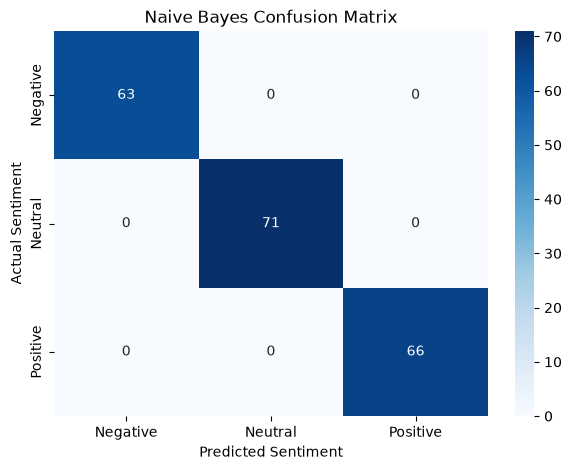

In [22]:
cm_nb = confusion_matrix(
    y_test,
    nb_pred,
    labels=['Negative', 'Neutral', 'Positive']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')

plt.show()

## Model 2 – Logistic Regression

Logistic Regression is a supervised machine learning algorithm that
can be used for multi-class classification.

In this project, Logistic Regression learns the relationship between
TF-IDF features and the three sentiment classes.

It is used as the second classifier so that its performance can be
compared with Multinomial Naive Bayes.

In [23]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [24]:
lr_accuracy = accuracy_score(y_test, lr_pred)

lr_precision = precision_score(
    y_test,
    lr_pred,
    average='weighted'
)

lr_recall = recall_score(
    y_test,
    lr_pred,
    average='weighted'
)

lr_f1 = f1_score(
    y_test,
    lr_pred,
    average='weighted'
)

print("Logistic Regression Results")
print("----------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Logistic Regression Results
----------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [25]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        63
     Neutral       1.00      1.00      1.00        71
    Positive       1.00      1.00      1.00        66

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



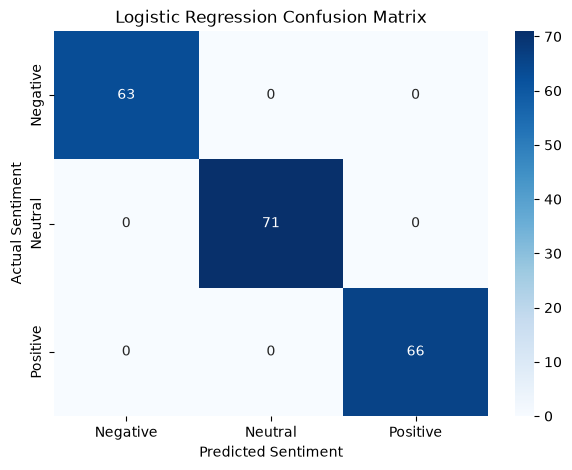

In [26]:
cm_lr = confusion_matrix(
    y_test,
    lr_pred,
    labels=['Negative', 'Neutral', 'Positive']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')

plt.show()

In [27]:
results = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'Logistic Regression'
    ],

    'Accuracy': [
        nb_accuracy,
        lr_accuracy
    ],

    'Precision': [
        nb_precision,
        lr_precision
    ],

    'Recall': [
        nb_recall,
        lr_recall
    ],

    'F1 Score': [
        nb_f1,
        lr_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,1.0,1.0,1.0,1.0
1,Logistic Regression,1.0,1.0,1.0,1.0


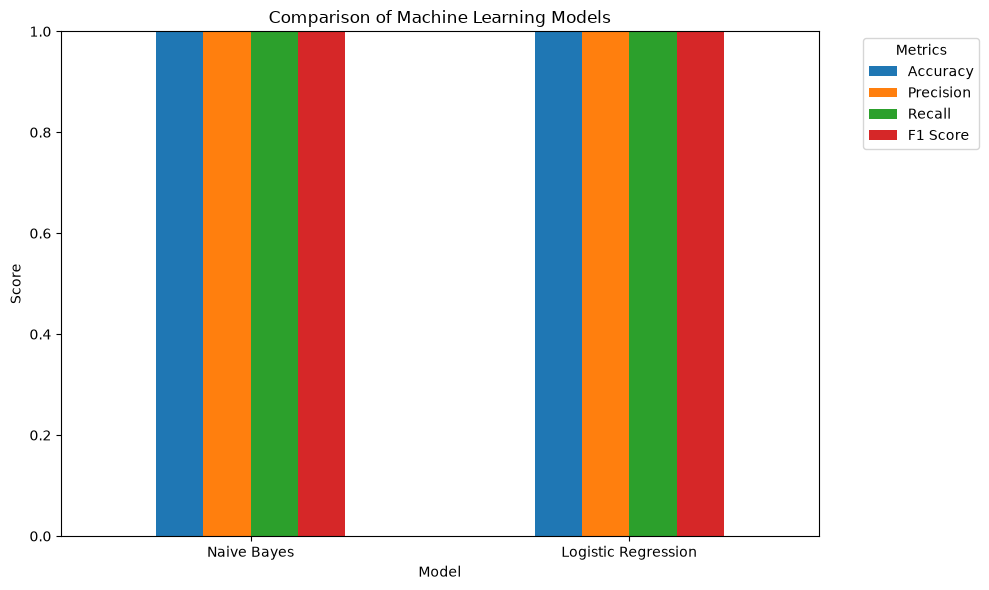

In [28]:
results.set_index('Model').plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Comparison of Machine Learning Models')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend(
    title='Metrics',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()

plt.show()

In [29]:
best_model = results.loc[
    results['F1 Score'].idxmax()
]

print("Best Model:", best_model['Model'])
print("F1 Score:", best_model['F1 Score'])

Best Model: Naive Bayes
F1 Score: 1.0


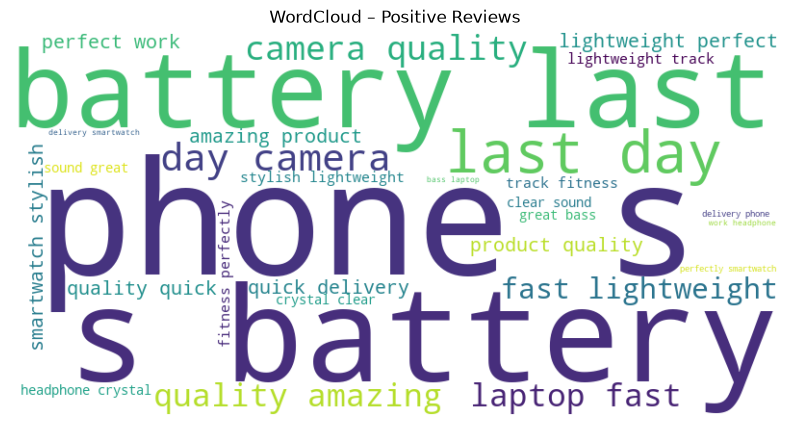

In [30]:
positive_text = ' '.join(
    df[df['Sentiment'] == 'Positive']['Clean_Review']
)

wordcloud_positive = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10, 5))

plt.imshow(
    wordcloud_positive,
    interpolation='bilinear'
)

plt.axis('off')

plt.title('WordCloud – Positive Reviews')

plt.show()

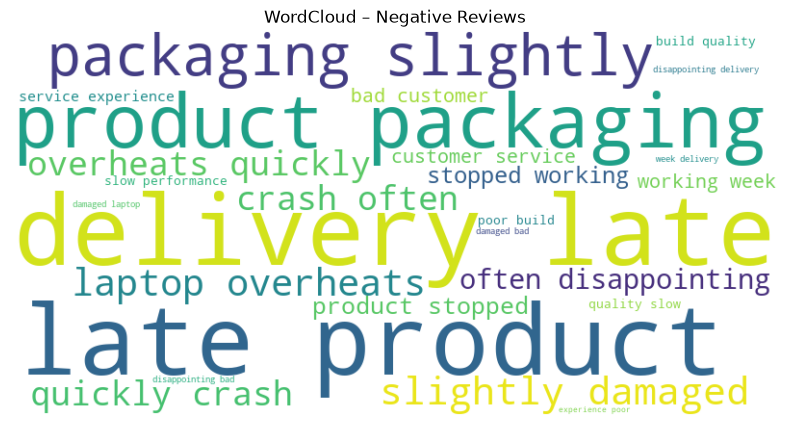

In [31]:
negative_text = ' '.join(
    df[df['Sentiment'] == 'Negative']['Clean_Review']
)

wordcloud_negative = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10, 5))

plt.imshow(
    wordcloud_negative,
    interpolation='bilinear'
)

plt.axis('off')

plt.title('WordCloud – Negative Reviews')

plt.show()

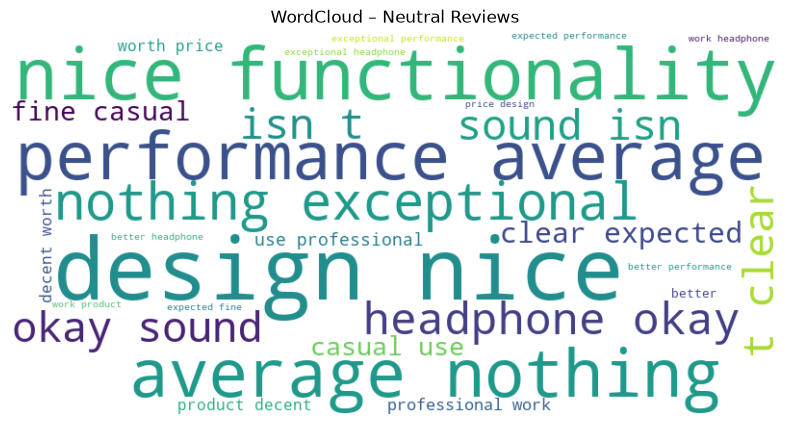

In [32]:
neutral_text = ' '.join(
    df[df['Sentiment'] == 'Neutral']['Clean_Review']
)

wordcloud_neutral = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(neutral_text)

plt.figure(figsize=(10, 5))

plt.imshow(
    wordcloud_neutral,
    interpolation='bilinear'
)

plt.axis('off')

plt.title('WordCloud – Neutral Reviews')

plt.show()

In [33]:
error_df = pd.DataFrame({
    'Review': df.loc[y_test.index, 'Review'],
    'Actual': y_test,
    'Predicted': lr_pred
})

errors = error_df[
    error_df['Actual'] != error_df['Predicted']
]

print("Number of misclassified reviews:", len(errors))

Number of misclassified reviews: 0


In [34]:
errors.head(5)

,Review,Actual,Predicted


In [35]:
for i, row in errors.head(5).iterrows():

    print("Review:", row['Review'])
    print("Actual Sentiment:", row['Actual'])
    print("Predicted Sentiment:", row['Predicted'])
    print("-" * 80)

## Error Analysis

The misclassified reviews were examined to understand why the model
made incorrect predictions.

Some possible reasons for misclassification include:

### 1. Mixed sentiment

A review may contain both positive and negative expressions. For
example, a review may say that a product is good but its
functionality could be improved.

### 2. Context

TF-IDF represents words statistically and does not fully understand
the context of a sentence.

### 3. Similar vocabulary

Different sentiment classes can contain similar words, which can
make classification difficult.

### 4. Limited vocabulary

The dataset contains a small number of unique review texts, so the
model has limited linguistic variety to learn from.

### 5. Negation

Expressions such as "not good" can be difficult for traditional
bag-of-words approaches because the meaning depends on the
relationship between words.

These limitations explain why some reviews may be incorrectly
classified.

In [36]:
new_review = [
    "The product is excellent and I am very happy with the quality."
]

new_review_clean = [
    preprocess_text(text)
    for text in new_review
]

new_review_tfidf = vectorizer.transform(
    new_review_clean
)

prediction = lr_model.predict(
    new_review_tfidf
)

print("Review:", new_review[0])
print("Predicted Sentiment:", prediction[0])

Review: The product is excellent and I am very happy with the quality.
Predicted Sentiment: Positive


In [37]:
new_review = [
    "The product is terrible and stopped working after two days."
]

In [38]:
new_review = [
    "The product is okay for normal use but nothing special."
]

# Conclusion

In this project, sentiment analysis was performed on product reviews
using Natural Language Processing and machine learning techniques.

The dataset contained 1,000 product reviews belonging to three
sentiment classes: Positive, Negative, and Neutral.

The text data was preprocessed using:

- Lowercase conversion
- Punctuation removal
- Number removal
- Tokenization
- Stopword removal
- Lemmatization

TF-IDF was used to convert the cleaned textual reviews into numerical
features.

Two machine learning models were trained:

1. Multinomial Naive Bayes
2. Logistic Regression

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

The model with the highest F1-score was considered the best
performing model for this dataset.

## Real-World Applications

Sentiment analysis can be used in many real-world applications,
including:

- Customer feedback analysis
- E-commerce product review analysis
- Customer service improvement
- Brand reputation monitoring
- Social media sentiment monitoring
- Product quality analysis
- Business decision-making

## Limitations

An important limitation of this dataset is that many review texts are
repeated. Although the dataset contains 1,000 records, it has limited
textual diversity. Therefore, the model performance may be higher
than what would be expected on a larger and more diverse real-world
dataset.

Future work could use a larger dataset containing unique and
naturally written customer reviews and could explore advanced NLP
models such as transformers.